In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from math import sqrt


In [22]:
df = pd.read_csv('../data/steam_clean.csv')
print("Dimensões:", df.shape)
df.head(3)


Dimensões: (24512, 15)


,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,positive_ratings,negative_ratings,average_playtime,owners,price,release_year
0,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,124534,3339,17612,10000000-20000000,7.19,2000
1,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,3318,633,277,5000000-10000000,3.99,1999
2,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,3416,398,187,5000000-10000000,3.99,2003


In [23]:
def parse_owners(x):
    try:
        a, b = x.split('-')
        return (int(a) + int(b)) / 2
    except:
        return np.nan

df['owners_mean'] = df['owners'].apply(parse_owners)

In [24]:
df['positive_ratio'] = df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'] + 1)

In [25]:
df['log_playtime'] = np.log1p(df['average_playtime'])

In [27]:
df = df.dropna(subset=['owners_mean', 'positive_ratio', 'log_playtime', 'price'])

In [28]:
features = [
    'owners_mean',
    'positive_ratio',
    'log_playtime',
    'release_year',
    'genres'
]
target = 'price'

X = df[features]
y = df[target]


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
cat_features = ['genres']
num_features = ['owners_mean', 'positive_ratio', 'log_playtime', 'release_year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [31]:
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"LinearRegression → RMSE: {rmse_lr:.2f} | R²: {r2_lr:.3f}")

LinearRegression → RMSE: 7.31 | R²: 0.013


In [32]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=14,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForest → RMSE: {rmse_rf:.2f} | R²: {r2_rf:.3f}")

RandomForest → RMSE: 6.69 | R²: 0.173


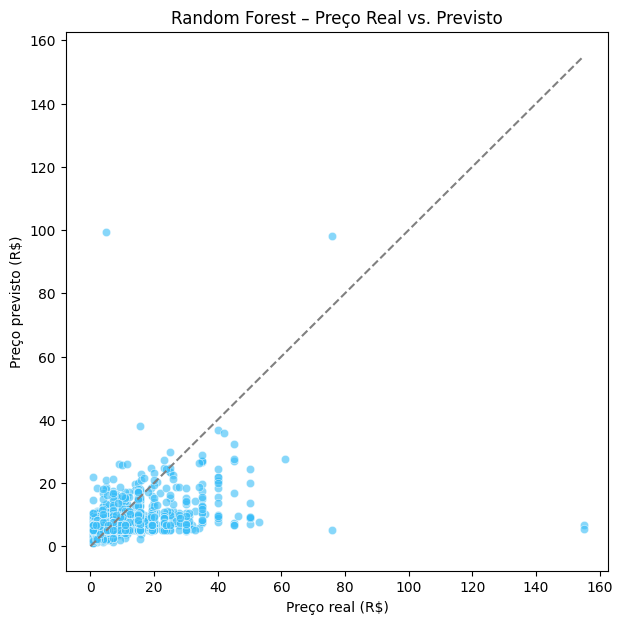

In [33]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred_rf, color="#38BDF8", alpha=0.6)
plt.xlabel("Preço real (R$)")
plt.ylabel("Preço previsto (R$)")
plt.title("Random Forest – Preço Real vs. Previsto")
plt.plot([0, max(y_test)], [0, max(y_test)], color='gray', linestyle='--')
plt.show()

In [34]:
import joblib
joblib.dump(rf, '../models/steam_price_model.pkl')
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
